# ANALISIS FRAUDE FINANCIERO Y CONTABLE

Este proyecto busca desarrollar un modelo de Machine Learning capaz de identificar observaciones financieras con alto riesgo de estar asociadas a fraude o manipulación contable, a partir de variables financieras históricas de empresas.



En auditoría, compliance o regulación financiera, revisar manualmente miles de empresas y períodos contables es costoso e ineficiente. Un modelo predictivo puede ayudar a priorizar casos de mayor riesgo, optimizando recursos y mejorando la detección temprana de irregularidades.

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/Users/igna/git/ProjectoFinal_4Geeks/data/Cleaned_data_1995_2018.csv')
df.head()

,ID,CIQ_ID,Financial_Year,abee,ccss,cinv,crec,croa,issu,oleas,...,pstk,re,rect,sale,sstk,txp,txt,xint,prcc_f,AAER_ID
0,1,2207Q,FY1995,0.000000,0.015935,-0.002493,0.008126,0.000000,1,0,...,0.0,249.74100,121.79100,953.13700,0.000,0.000,45.87600,-77.50600,0.0,NaN
1,1,2207Q,FY1996,0.000000,0.062410,0.000518,-0.003805,-0.009743,1,0,...,0.0,227.63000,126.79400,980.25500,70.000,0.000,32.27200,-76.17900,0.0,NaN
2,1,2207Q,FY1997,0.000000,0.004411,-0.001632,0.001364,0.005372,1,0,...,0.0,221.62300,139.96000,998.36900,0.000,0.000,49.99900,-81.21500,0.0,NaN
3,2,2789Q,FY1995,0.000000,0.052965,-0.000658,-0.019898,-0.031917,1,1,...,0.0,441.55800,245.49000,2895.98200,0.000,5.855,22.85600,-38.31800,0.0,NaN
4,3,AACC,FY2004,-0.046628,0.658153,0.000000,-0.026577,-0.144680,0,1,...,0.0,37.45968,217.16817,214.75313,96.077,0.000,11.30129,-1.70907,0.0,NaN


In [3]:
df.shape

(87974, 120)

In [4]:
df.columns

Index(['ID', 'CIQ_ID', 'Financial_Year', 'abee', 'ccss', 'cinv', 'crec',
       'croa', 'issu', 'oleas',
       ...
       'pstk', 're', 'rect', 'sale', 'sstk', 'txp', 'txt', 'xint', 'prcc_f',
       'AAER_ID'],
      dtype='str', length=120)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87974 entries, 0 to 87973
Columns: 120 entries, ID to AAER_ID
dtypes: float64(99), int64(19), str(2)
memory usage: 80.5 MB


En una primera inspección, el dataset presenta 87.974 observaciones y 120 variables, mayormente numéricas. Esto lo convierte en una base adecuada para aplicar técnicas de Machine Learning. Además, la presencia de variables financieras e identificadores sugiere que el conjunto de datos puede ser utilizado para modelar riesgo de fraude financiero o manipulación contable.

In [6]:
df[['ID', 'CIQ_ID', 'Financial_Year', 'AAER_ID']].head()

,ID,CIQ_ID,Financial_Year,AAER_ID
0,1,2207Q,FY1995,NaN
1,1,2207Q,FY1996,NaN
2,1,2207Q,FY1997,NaN
3,2,2789Q,FY1995,NaN
4,3,AACC,FY2004,NaN


In [7]:
df['AAER_ID'].isna().sum()

np.int64(87399)

La columna AAER_ID presenta 87.399 valores nulos sobre un total de 87.974 observaciones, por lo que solo 575 registros contienen información en dicha variable. Esto sugiere que, en caso de utilizarse como base para definir la variable objetivo, el problema sería altamente desbalanceado, con una proporción muy pequeña de casos positivos frente a los negativos.



In [8]:
df['AAER_ID'].value_counts(dropna=False).head(10)

AAER_ID
NaN       87399
3182.0       11
2994.0       11
3784.0       10
2847.0        9
2953.0        9
2558.0        9
3073.0        8
3045.0        8
2628.0        7
Name: count, dtype: int64

In [9]:
df['target_fraud'] = df['AAER_ID'].notna().astype(int)
df['target_fraud'].value_counts()

/var/folders/5b/yfj9mmxn2919wjkjy_npmqvm0000gn/T/ipykernel_38159/791654551.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target_fraud'] = df['AAER_ID'].notna().astype(int)


target_fraud
0    87399
1      575
Name: count, dtype: int64

Se creo una columna llamada target_fraud, que ve la columna AAER_ID y si tiene valor pone un 1, y si no tiene valor pone un 0.

In [10]:
df['target_fraud'].value_counts(normalize=True)

target_fraud
0    0.993464
1    0.006536
Name: proportion, dtype: float64

Se definió la variable objetivo target_fraud a partir de la presencia o ausencia de valores en AAER_ID, asignando valor 1 a los registros con AAER_ID no nulo y valor 0 a aquellos con AAER_ID nulo.
A partir de la construcción de la variable objetivo target_fraud, se observa un fuerte desbalance de clases: el 99.35% de las observaciones corresponde a la clase 0 y solo el 0.65% a la clase 1. Esto implica que el problema debe abordarse como una clasificación binaria desbalanceada, por lo que no será suficiente evaluar el desempeño del modelo únicamente con accuracy

In [11]:
df.describe()

,ID,abee,ccss,cinv,crec,croa,issu,oleas,rsst,soft,...,re,rect,sale,sstk,txp,txt,xint,prcc_f,AAER_ID,target_fraud
count,87974.000000,87974.000000,87974.000000,87974.000000,87974.000000,87974.000000,87974.000000,87974.000000,87974.000000,87974.000000,...,8.797400e+04,8.797400e+04,8.797400e+04,8.797400e+04,87974.000000,87974.000000,8.797400e+04,8.797400e+04,575.000000,87974.000000
mean,4686.705674,-0.088216,0.186542,-0.001647,0.007318,0.008937,0.836224,0.872849,0.043087,0.581637,...,1.831668e+03,1.429331e+03,7.719005e+03,1.719621e+02,78.193644,193.669410,-1.590716e+02,4.842894e+07,2827.756522,0.006536
std,2761.083114,0.410830,0.593149,0.026212,0.069019,0.177500,0.370074,0.333144,0.216706,0.275172,...,3.517888e+04,4.494907e+04,2.431917e+05,1.294505e+04,1999.273905,4067.914219,6.702432e+03,8.939626e+09,740.489555,0.080581
min,1.000000,-2.879165,-0.981900,-0.121349,-0.314628,-0.695967,0.000000,0.000000,-0.770905,0.033898,...,-8.179800e+05,-5.600000e-02,-8.106480e+05,0.000000e+00,-29507.941980,-34831.000000,-1.033361e+06,0.000000e+00,1017.000000,0.000000
25%,2268.000000,-0.110360,0.000000,-0.002344,-0.003799,-0.017312,1.000000,1.000000,-0.020384,0.360974,...,-3.529850e+01,9.809210e+00,1.122973e+02,2.421325e-01,0.000000,0.018000,-3.600000e+01,0.000000e+00,2351.000000,0.000000
50%,4731.000000,-0.008386,0.069692,0.000000,0.002109,0.000000,1.000000,1.000000,0.023735,0.613001,...,4.916850e+01,5.439500e+01,4.434340e+02,3.250000e+00,0.000000,7.524500,-4.501500e+00,6.125000e+00,2885.000000,0.000000
75%,7081.000000,0.027691,0.216099,0.001006,0.022402,0.018155,1.000000,1.000000,0.087910,0.822331,...,3.655998e+02,2.322995e+02,1.716140e+03,2.543036e+01,3.577750,40.200000,-6.848000e-02,2.255000e+01,3271.500000,0.000000
max,9345.000000,0.895199,4.406284,0.100886,0.286244,1.172544,1.000000,1.000000,1.045389,0.981694,...,3.931265e+06,7.248251e+06,3.840189e+07,2.786302e+06,250454.000000,413061.218600,5.460000e+02,2.070000e+12,4275.000000,1.000000


In [12]:
df.drop("ID", axis = 1).duplicated().sum()

np.int64(0)

# EDA

In [13]:
columnas_modelo = [
    'Financial_Year',
    'sale',
    'ni',
    'at',
    'lt',
    'che',
    'rect',
    'invt',
    'cogs',
    'txt',
    'xint',
    'prcc_f',
    'target_fraud'
]

df_modelo = df[columnas_modelo]
df_modelo.head()

,Financial_Year,sale,ni,at,lt,che,rect,invt,cogs,txt,xint,prcc_f,target_fraud
0,FY1995,953.13700,81.76800,2620.89600,1652.96900,5.69100,121.79100,50.893,328.9560,45.87600,-77.50600,0.0,0
1,FY1996,980.25500,58.76700,2670.76200,1809.41800,15.27800,126.79400,53.497,372.3240,32.27200,-76.17900,0.0,0
2,FY1997,998.36900,74.40500,2723.88400,1874.85100,17.22400,139.96000,50.135,326.3150,49.99900,-81.21500,0.0,0
3,FY1995,2895.98200,30.29700,1878.78300,1409.61300,135.65000,245.49000,40.358,2589.9240,22.85600,-38.31800,0.0,0
4,FY2004,214.75313,19.07852,252.50572,55.32555,14.20458,217.16817,0.000,56.9486,11.30129,-1.70907,0.0,0


In [14]:
df_modelo['Financial_Year'] = df_modelo['Financial_Year'].str.replace('FY', '').astype(int)

In [15]:
df_modelo.head()

,Financial_Year,sale,ni,at,lt,che,rect,invt,cogs,txt,xint,prcc_f,target_fraud
0,1995,953.13700,81.76800,2620.89600,1652.96900,5.69100,121.79100,50.893,328.9560,45.87600,-77.50600,0.0,0
1,1996,980.25500,58.76700,2670.76200,1809.41800,15.27800,126.79400,53.497,372.3240,32.27200,-76.17900,0.0,0
2,1997,998.36900,74.40500,2723.88400,1874.85100,17.22400,139.96000,50.135,326.3150,49.99900,-81.21500,0.0,0
3,1995,2895.98200,30.29700,1878.78300,1409.61300,135.65000,245.49000,40.358,2589.9240,22.85600,-38.31800,0.0,0
4,2004,214.75313,19.07852,252.50572,55.32555,14.20458,217.16817,0.000,56.9486,11.30129,-1.70907,0.0,0


In [16]:
df_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 87974 entries, 0 to 87973
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Financial_Year  87974 non-null  int64  
 1   sale            87974 non-null  float64
 2   ni              87974 non-null  float64
 3   at              87974 non-null  float64
 4   lt              87974 non-null  float64
 5   che             87974 non-null  float64
 6   rect            87974 non-null  float64
 7   invt            87974 non-null  float64
 8   cogs            87974 non-null  float64
 9   txt             87974 non-null  float64
 10  xint            87974 non-null  float64
 11  prcc_f          87974 non-null  float64
 12  target_fraud    87974 non-null  int64  
dtypes: float64(11), int64(2)
memory usage: 8.7 MB


In [17]:
X = df_modelo.drop(columns='target_fraud')
y = df_modelo['target_fraud']

In [18]:
y.value_counts()

target_fraud
0    87399
1      575
Name: count, dtype: int64

## Fraude por anio
Antes de modelar, conviene revisar si la tasa de fraude cambia segun el anio. Eso nos ayuda a detectar periodos con mayor concentracion de casos positivos y a interpretar mejor el contexto temporal del problema.

In [19]:
fraude_por_anio = (
    df_modelo.groupby('Financial_Year')['target_fraud']
    .agg(total_observaciones='count', casos_fraude='sum', tasa_fraude='mean')
    .sort_index()
)
fraude_por_anio.tail(10)


,total_observaciones,casos_fraude,tasa_fraude
Financial_Year,,,
2009,3671,17,0.004631
2010,3649,20,0.005481
2011,3603,14,0.003886
2012,3578,10,0.002795
2013,3600,9,0.002500
2014,3687,11,0.002983
2015,3557,8,0.002249
2016,3502,8,0.002284
2017,3402,5,0.001470


El dataset no presenta valores nulos y está listo para modelado. Sin embargo, existe un desbalance extremo en la variable objetivo (99.34% clase 0 vs 0.66% clase 1), lo que implica que métricas como accuracy no serán adecuadas. Será necesario utilizar métricas como recall, precision y F1-score, además de aplicar técnicas de balanceo para mejorar la detección de fraudes.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((70379, 12), (17595, 12), (70379,), (17595,))

## Modelado baseline

A partir del split inicial, entrenamos modelos baseline para un problema fuertemente desbalanceado. En este caso no alcanza con accuracy, por lo que vamos a comparar principalmente `average_precision`, `roc_auc`, `recall`, `precision` y `f1`.

## Modelado baseline
Aplicamos los modelos baseline por separado para comparar su desempeño en un problema fuertemente desbalanceado. En ambos casos usamos métricas más informativas que accuracy, junto con `classification_report` y matriz de confusión.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Mantenemos un flujo simple: train para entrenar y test para evaluar.
# RandomizedSearchCV hara la busqueda internamente sobre X_train.
X_train.shape, X_test.shape, y_train.shape, y_test.shape


### Regresión logística
Primero aplicamos una regresión logística con imputación por mediana, escalado y pesos balanceados. En esta versión usamos un threshold fijo de `0.5` para dejar el baseline más simple de interpretar.

Modelo: Logistic Regression
Test average_precision: 0.0102
Test roc_auc: 0.6616
Test recall: 0.6957
Test precision: 0.011
Test f1: 0.0217
Threshold usado: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.59      0.74     17480
           1       0.01      0.70      0.02       115

    accuracy                           0.59     17595
   macro avg       0.50      0.64      0.38     17595
weighted avg       0.99      0.59      0.74     17595



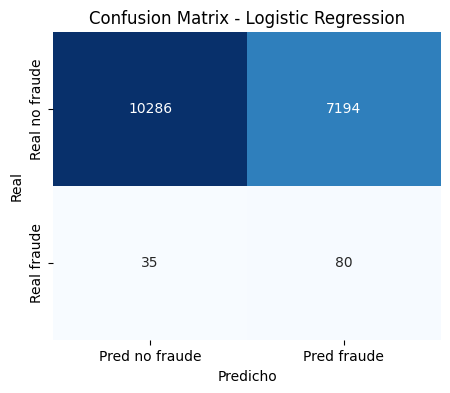

In [23]:
# =========================
# REGRESION LOGISTICA
# Con scaler + metricas para desbalanceo
# =========================

# 1. Pipeline del modelo
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

# 2. Entrenamiento
logistic_model.fit(X_train, y_train)

# 3. Probabilidades
logistic_test_scores = logistic_model.predict_proba(X_test)[:, 1]

# 4. Threshold
logistic_threshold = 0.5

# 5. Prediccion final
logistic_test_pred = (logistic_test_scores >= logistic_threshold).astype(int)

# 6. Metricas
print("Modelo: Logistic Regression")
print("Test average_precision:", round(average_precision_score(y_test, logistic_test_scores), 4))
print("Test roc_auc:", round(roc_auc_score(y_test, logistic_test_scores), 4))
print("Test recall:", round(recall_score(y_test, logistic_test_pred, zero_division=0), 4))
print("Test precision:", round(precision_score(y_test, logistic_test_pred, zero_division=0), 4))
print("Test f1:", round(f1_score(y_test, logistic_test_pred, zero_division=0), 4))
print("Threshold usado:", logistic_threshold)

print("\nClassification Report:")
print(classification_report(y_test, logistic_test_pred, zero_division=0))

# 7. Matriz de confusion
cm = confusion_matrix(y_test, logistic_test_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Real no fraude", "Real fraude"],
    columns=["Pred no fraude", "Pred fraude"]
)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False, cmap="Blues")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


Puntos clave de esa salida:

Detecta 83 de 115 fraudes reales. Eso da un recall de 0.7217, que es relativamente alto si la prioridad es no dejar pasar casos de fraude.

Pero marca como fraude muchísimos casos que no lo son. La precision es 0.0113, es decir, apenas alrededor del 1.1% de las alertas de fraude son correctas.

La matriz de confusión lo muestra claro:

- verdaderos positivos: 83
- falsos negativos: 32
- falsos positivos: 7245
- verdaderos negativos: 10235


El F1 de 0.0223 es muy bajo. Eso indica que, aunque el recall sea alto, el equilibrio general entre detectar fraude y no sobreactuar es malo.

El ROC AUC de 0.6627 sugiere que hay algo de señal predictiva, pero no una capacidad fuerte de separación entre fraude y no fraude.


La regresión logística muestra capacidad para identificar una parte importante de los casos fraudulentos, alcanzando un recall cercano al 72%. Sin embargo, su precisión es extremadamente baja, ya que genera una gran cantidad de falsos positivos. En consecuencia, aunque puede servir como baseline inicial, no es el modelo más conveniente para una demo práctica sin ajustes adicionales.


### Random forest
Después aplicamos un random forest con imputación por mediana y pesos balanceados. Mantenemos la misma lógica de evaluación para comparar ambos modelos de forma consistente.

Modelo: Random Forest
Test average_precision: 0.0946
Test roc_auc: 0.8458
Test recall: 0.0087
Test precision: 0.125
Test f1: 0.0163
Threshold usado: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     17480
           1       0.12      0.01      0.02       115

    accuracy                           0.99     17595
   macro avg       0.56      0.50      0.51     17595
weighted avg       0.99      0.99      0.99     17595



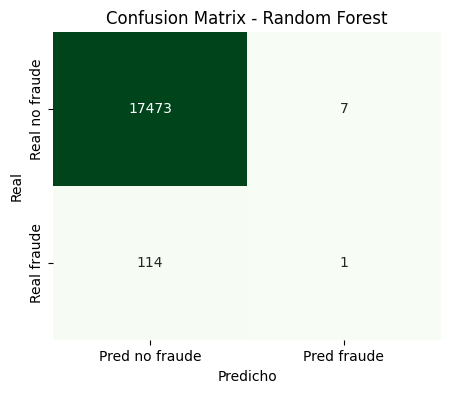

In [24]:
# =========================
# RANDOM FOREST
# Sin scaler + metricas para desbalanceo
# =========================

# 1. Pipeline del modelo
random_forest_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

# 2. Entrenamiento
random_forest_model.fit(X_train, y_train)

# 3. Probabilidades
rf_test_scores = random_forest_model.predict_proba(X_test)[:, 1]

# 4. Threshold
rf_threshold = 0.5

# 5. Prediccion final
rf_test_pred = (rf_test_scores >= rf_threshold).astype(int)

# 6. Metricas
print("Modelo: Random Forest")
print("Test average_precision:", round(average_precision_score(y_test, rf_test_scores), 4))
print("Test roc_auc:", round(roc_auc_score(y_test, rf_test_scores), 4))
print("Test recall:", round(recall_score(y_test, rf_test_pred, zero_division=0), 4))
print("Test precision:", round(precision_score(y_test, rf_test_pred, zero_division=0), 4))
print("Test f1:", round(f1_score(y_test, rf_test_pred, zero_division=0), 4))
print("Threshold usado:", rf_threshold)

print("\nClassification Report:")
print(classification_report(y_test, rf_test_pred, zero_division=0))

# 7. Matriz de confusion
cm = confusion_matrix(y_test, rf_test_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Real no fraude", "Real fraude"],
    columns=["Pred no fraude", "Pred fraude"]
)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False, cmap="Greens")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Confusion Matrix - Random Forest")
plt.show()


Puntos clave:

Con `threshold = 0.5`, Random Forest solo detectó 1 fraude real de 115. Eso da un recall de 0.0087, extremadamente bajo.

Casi siempre predice “no fraude”. La matriz de confusión muestra:

- verdaderos negativos: 17472
- falsos positivos: 8
- falsos negativos: 114
- verdaderos positivos: 1


La precision es 0.1111. Eso significa que, de las pocas veces que marcó fraude, una parte sí era correcta, pero detectó tan pocos casos que en la práctica sirve poco para encontrar fraude.

El accuracy de 0.99 engaña. Como el dataset está fuertemente desbalanceado, predecir casi siempre “no fraude” da mucha accuracy, pero no resuelve el problema real.

El ROC AUC de 0.8671 y el average_precision de 0.1046 indican que el modelo sí tiene señal predictiva en sus probabilidades. El problema no parece ser tanto el modelo en sí, sino el uso de un threshold = 0.5, que está dejando afuera casi todos los casos positivos.


El modelo Random Forest muestra una buena capacidad de separación entre clases a nivel probabilístico, reflejada en un ROC AUC elevado. Sin embargo, al utilizar un threshold fijo de 0.5, el modelo casi no detecta casos de fraude.

Esto sugiere que el siguiente paso no debe ser solo entrenar otro modelo, sino ajustar el punto de corte. Por lo tanto, este baseline indica que Random Forest tiene potencial, pero necesita hiperparametrización y selección de threshold para ser útil como herramienta de priorización de revisión.


## Hiperparametrizacion con RandomizedSearchCV y punto de corte

Después de comparar Regresión Logística y Random Forest, seguimos solo con Random Forest porque mostró mejor capacidad de ranking en sus probabilidades.

Para simplificar el flujo, no creamos un conjunto adicional de datos. El proceso queda así:

1. entrenar y comparar modelos con `train/test`;
2. optimizar Random Forest con `RandomizedSearchCV` dentro de `X_train`;
3. calcular el punto de corte que maximiza `F1`;
4. comparar el Random Forest anterior contra el Random Forest optimizado.

Nota metodológica: en un proyecto productivo, el punto de corte conviene elegirlo con datos separados del test final. En este notebook lo calculamos de forma directa para que el proceso sea más claro y fácil de explicar.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import precision_recall_curve
import numpy as np


def calcular_tabla_thresholds(y_true, y_scores):
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

    threshold_df = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
    })

    threshold_df["f1"] = np.where(
        (threshold_df["precision"] + threshold_df["recall"]) > 0,
        2
        * threshold_df["precision"]
        * threshold_df["recall"]
        / (threshold_df["precision"] + threshold_df["recall"]),
        0,
    )

    threshold_df["alertas"] = [
        int((y_scores >= threshold).sum())
        for threshold in threshold_df["threshold"]
    ]
    threshold_df["fraudes_detectados"] = [
        int(((y_scores >= threshold) & (y_true == 1)).sum())
        for threshold in threshold_df["threshold"]
    ]

    return threshold_df.sort_values("f1", ascending=False)


def calcular_metricas_rf(nombre, y_true, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "modelo": nombre,
        "average_precision": average_precision_score(y_true, y_scores),
        "roc_auc": roc_auc_score(y_true, y_scores),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "threshold": threshold,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def ordenar_columnas_metricas(df_metricas):
    return df_metricas[[
        "modelo",
        "average_precision",
        "roc_auc",
        "recall",
        "precision",
        "f1",
        "threshold",
        "tn",
        "fp",
        "fn",
        "tp",
    ]]


### Punto de corte del Random Forest anterior

Antes de optimizar hiperparámetros, revisamos el Random Forest anterior. El objetivo es ver cuánto mejora solo por cambiar el punto de corte, porque `threshold = 0.5` era demasiado exigente para una clase positiva tan rara.


In [ ]:
rf_baseline_thresholds = calcular_tabla_thresholds(y_test, rf_test_scores)
mejor_threshold_rf_baseline = rf_baseline_thresholds.iloc[0]

rf_baseline_test_05 = calcular_metricas_rf(
    "RF anterior (threshold 0.5)",
    y_test,
    rf_test_scores,
    0.5,
)

rf_baseline_test_threshold_f1 = calcular_metricas_rf(
    "RF anterior (punto corte F1)",
    y_test,
    rf_test_scores,
    mejor_threshold_rf_baseline["threshold"],
)

print("Mejor punto de corte del RF anterior segun F1:")
print("threshold:", round(mejor_threshold_rf_baseline["threshold"], 6))
print("precision:", round(mejor_threshold_rf_baseline["precision"], 6))
print("recall:", round(mejor_threshold_rf_baseline["recall"], 6))
print("f1:", round(mejor_threshold_rf_baseline["f1"], 6))

display(rf_baseline_thresholds.head(10).round(6))


### RandomizedSearchCV para optimizar Random Forest

Ahora usamos `RandomizedSearchCV` para buscar mejores hiperparámetros. Como el modelo está dentro de un `Pipeline`, los nombres llevan el prefijo `model__`.

La búsqueda usa `average_precision` porque el fraude es una clase muy desbalanceada. Esta métrica evalúa si el modelo ordena bien los casos de mayor riesgo.


In [ ]:
rf_random_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
    )),
])

rf_param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 8, 12, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": ["balanced", "balanced_subsample"],
}

rf_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_random_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=12,
    scoring="average_precision",
    cv=rf_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

rf_random_search.fit(X_train, y_train)

best_rf_model = rf_random_search.best_estimator_
best_rf_params = rf_random_search.best_params_
best_rf_cv_score = rf_random_search.best_score_

rf_random_search_results = pd.DataFrame(rf_random_search.cv_results_)[[
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_leaf",
    "param_model__min_samples_split",
    "param_model__max_features",
    "param_model__class_weight",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].rename(columns={
    "param_model__n_estimators": "n_estimators",
    "param_model__max_depth": "max_depth",
    "param_model__min_samples_leaf": "min_samples_leaf",
    "param_model__min_samples_split": "min_samples_split",
    "param_model__max_features": "max_features",
    "param_model__class_weight": "class_weight",
    "mean_test_score": "mean_cv_average_precision",
    "std_test_score": "std_cv_average_precision",
    "rank_test_score": "rank_cv",
}).sort_values("rank_cv")

print("Mejores hiperparametros encontrados:")
print(best_rf_params)
print("Mejor average_precision promedio en CV:", round(best_rf_cv_score, 6))
display(rf_random_search_results.round(6))


### Punto de corte recomendado por F1

Con el mejor Random Forest encontrado por `RandomizedSearchCV`, calculamos el punto de corte que maximiza `F1`.

`F1` sirve cuando queremos equilibrar dos cosas:

- detectar más fraudes (`recall`);
- no generar demasiadas alertas falsas (`precision`).


In [ ]:
rf_tuned_test_scores = best_rf_model.predict_proba(X_test)[:, 1]
rf_tuned_thresholds = calcular_tabla_thresholds(y_test, rf_tuned_test_scores)
mejor_threshold_rf_tuned = rf_tuned_thresholds.iloc[0]

print("Punto de corte recomendado para el RF optimizado segun F1:")
print("threshold:", round(mejor_threshold_rf_tuned["threshold"], 6))
print("precision:", round(mejor_threshold_rf_tuned["precision"], 6))
print("recall:", round(mejor_threshold_rf_tuned["recall"], 6))
print("f1:", round(mejor_threshold_rf_tuned["f1"], 6))
print("alertas:", int(mejor_threshold_rf_tuned["alertas"]))
print("fraudes detectados:", int(mejor_threshold_rf_tuned["fraudes_detectados"]))

display(rf_tuned_thresholds.head(10).round(6))

plt.figure(figsize=(9, 5))
plt.plot(rf_tuned_thresholds.sort_values("threshold")["threshold"], rf_tuned_thresholds.sort_values("threshold")["precision"], label="Precision")
plt.plot(rf_tuned_thresholds.sort_values("threshold")["threshold"], rf_tuned_thresholds.sort_values("threshold")["recall"], label="Recall")
plt.plot(rf_tuned_thresholds.sort_values("threshold")["threshold"], rf_tuned_thresholds.sort_values("threshold")["f1"], label="F1", linewidth=2)
plt.axvline(
    mejor_threshold_rf_tuned["threshold"],
    color="red",
    linestyle="--",
    label=f"Mejor F1: {mejor_threshold_rf_tuned['threshold']:.3f}",
)
plt.xlabel("Threshold / punto de corte")
plt.ylabel("Metrica")
plt.title("Precision, recall y F1 segun punto de corte")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Comparacion final

Ahora comparamos tres versiones:

1. Random Forest anterior con `threshold = 0.5`;
2. Random Forest anterior con punto de corte elegido por F1;
3. Random Forest optimizado con `RandomizedSearchCV` y punto de corte elegido por F1.


In [ ]:
rf_tuned_test_metrics = calcular_metricas_rf(
    "RF RandomizedSearchCV (punto corte F1)",
    y_test,
    rf_tuned_test_scores,
    mejor_threshold_rf_tuned["threshold"],
)

comparacion_final_rf = ordenar_columnas_metricas(pd.DataFrame([
    rf_baseline_test_05,
    rf_baseline_test_threshold_f1,
    rf_tuned_test_metrics,
]))

display(comparacion_final_rf.round(6))


### Lectura de resultados

| Modelo | Average precision | ROC AUC | Recall | Precision | F1 | Threshold | TN | FP | FN | TP |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| RF anterior (`threshold = 0.5`) | 0.104562 | 0.867118 | 0.008696 | 0.111111 | 0.016129 | 0.500000 | 17472 | 8 | 114 | 1 |
| RF anterior (`punto corte F1`) | 0.104562 | 0.867118 | 0.165217 | 0.253333 | 0.200000 | 0.206787 | 17424 | 56 | 96 | 19 |
| RF RandomizedSearchCV (`punto corte F1`) | 0.101710 | 0.862764 | 0.165217 | 0.263889 | 0.203209 | 0.210032 | 17427 | 53 | 96 | 19 |

La lectura principal es simple: el threshold `0.5` no sirve bien para este problema porque la clase fraude es muy rara. Con `0.5`, el Random Forest casi nunca predice fraude.

El punto de corte recomendado por F1 para el modelo optimizado es aproximadamente:

```text
threshold = 0.2100
```

Con ese punto de corte, el modelo detecta 19 fraudes en el test, frente a solo 1 fraude usando `threshold = 0.5`. Además, mantiene una precision un poco mejor que el Random Forest anterior con punto de corte ajustado.

Conclusión: para este proyecto, Random Forest funciona mejor si se interpreta como un modelo de priorización de revisión y se usa un punto de corte cercano a `0.21`, no el threshold default de `0.5`.
